In [8]:
# Install required packages
!pip install kagglehub torch torchvision pydicom opencv-python matplotlib pandas

# Import libraries
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os
import kagglehub
import pydicom
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import time

# Verify GPU
!nvidia-smi
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if device.type == "cpu":
    print("WARNING: GPU not available. Training will be slow. Go to Runtime > Change runtime type > GPU and restart.")
print(f"Using device: {device}")

RuntimeError: Only a single TORCH_LIBRARY can be used to register the namespace prims; please put all of your definitions in a single TORCH_LIBRARY block.  If you were trying to specify implementations, consider using TORCH_LIBRARY_IMPL (which can be duplicated).  If you really intended to define operators for a single namespace in a distributed way, you can use TORCH_LIBRARY_FRAGMENT to explicitly indicate this.  Previous registration of TORCH_LIBRARY was registered at /dev/null:241; latest registration was registered at /dev/null:241

In [ ]:
# Custom Dataset class
class BrainCTDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        try:
            if img_path.lower().endswith('.dcm'):
                dcm = pydicom.dcmread(img_path)
                image = dcm.pixel_array.astype(float)
                window_center = 40
                window_width = 80
                min_value = window_center - window_width // 2
                max_value = window_center + window_width // 2
                image = np.clip(image, min_value, max_value)
                if len(image.shape) == 2:
                    image = np.stack([image] * 3, axis=-1)
            else:
                image = cv2.imread(img_path)
                if image is None:
                    raise ValueError(f"Failed to load image: {img_path}")
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-7)
            image = image.astype(np.float32)
            if self.transform:
                image = self.transform(torch.from_numpy(image).permute(2, 0, 1))
            return image, label
        except Exception as e:
            print(f"Error processing image {img_path}: {str(e)}")
            return None, None

# Load dataset
def load_dataset(base_path, max_samples_per_class=100, random_seed=42):
    np.random.seed(random_seed)
    image_paths = []
    labels = []
    aneurysm_path = os.path.join(base_path, 'aneurysm')
    if os.path.exists(aneurysm_path):
        aneurysm_files = [os.path.join(aneurysm_path, f) for f in os.listdir(aneurysm_path)
                         if f.endswith(('.jpg', '.dcm'))]
        n_aneurysm = min(len(aneurysm_files), max_samples_per_class)
        selected_aneurysm = np.random.choice(aneurysm_files, n_aneurysm, replace=False)
        image_paths.extend(selected_aneurysm)
        labels.extend([1] * n_aneurysm)
    other_files = []
    for category in ['tumor', 'cancer']:
        category_path = os.path.join(base_path, category)
        if os.path.exists(category_path):
            other_files.extend([os.path.join(category_path, f) for f in os.listdir(category_path)
                               if f.endswith(('.jpg', '.dcm'))])
    n_other = min(len(other_files), max_samples_per_class)
    selected_other = np.random.choice(other_files, n_other, replace=False)
    image_paths.extend(selected_other)
    labels.extend([0] * n_other)
    return image_paths, labels

In [ ]:
# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
print("Loading dataset...")
dataset_path = kagglehub.dataset_download("trainingdatapro/computed-tomography-ct-of-the-brain")
base_path = os.path.join(dataset_path, 'files')
image_paths, labels = load_dataset(base_path, max_samples_per_class=100)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

# Create datasets
train_dataset = BrainCTDataset(train_paths, train_labels, transform=transform)
test_dataset = BrainCTDataset(test_paths, test_labels, transform=transform)

# Create data loaders
batch_size = 64 if torch.cuda.is_available() else 16
num_workers = 4 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

Loading dataset...


100%|██████████| 66.0M/66.0M [00:00<00:00, 162MB/s]

Extracting files...


In [ ]:
# Define model with frozen layers
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.vgg16 = models.vgg16(weights='IMAGENET1K_V1')
        for param in self.vgg16.features.parameters():
            param.requires_grad = False
        in_feats = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_feats, 2)
    def forward(self, x):
        x = self.vgg16(x)
        return x

In [ ]:
# Initialize model, loss, and optimizer
model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001)

# Training with progress
epochs = 5
print("Starting training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    start_time = time.time()
    for i, batch in enumerate(train_loader):
        inputs, labels = batch
        if inputs is None:
            continue
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        print(f"[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / (i + 1):.4f}, Time: {time.time() - start_time:.2f}s")
    print(f"Epoch {epoch + 1} completed in {time.time() - start_time:.2f}s")

# Save the trained model
torch.save(model.state_dict(), 'model.pth')
print("Model saved as 'model.pth'")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:06<00:00, 88.5MB/s]


Starting training...
[Epoch 1, Batch 1] Loss: 0.7110, Time: 15.86s
[Epoch 1, Batch 2] Loss: 0.7539, Time: 29.20s
[Epoch 1, Batch 3] Loss: 0.7193, Time: 42.44s
[Epoch 1, Batch 4] Loss: 0.7098, Time: 55.63s
[Epoch 1, Batch 5] Loss: 0.6875, Time: 68.84s
[Epoch 1, Batch 6] Loss: 0.6591, Time: 82.00s
[Epoch 1, Batch 7] Loss: 0.6426, Time: 96.30s
[Epoch 1, Batch 8] Loss: 0.6228, Time: 109.44s
[Epoch 1, Batch 9] Loss: 0.6204, Time: 122.61s
[Epoch 1, Batch 10] Loss: 0.5996, Time: 135.81s
Epoch 1 completed in 135.81s
[Epoch 2, Batch 1] Loss: 0.3681, Time: 13.15s
[Epoch 2, Batch 2] Loss: 0.4521, Time: 26.26s
[Epoch 2, Batch 3] Loss: 0.4301, Time: 39.32s
[Epoch 2, Batch 4] Loss: 0.4288, Time: 52.34s
[Epoch 2, Batch 5] Loss: 0.4100, Time: 65.33s
[Epoch 2, Batch 6] Loss: 0.4059, Time: 78.37s
[Epoch 2, Batch 7] Loss: 0.4137, Time: 91.56s
[Epoch 2, Batch 8] Loss: 0.4127, Time: 104.62s
[Epoch 2, Batch 9] Loss: 0.4115, Time: 117.61s
[Epoch 2, Batch 10] Loss: 0.4120, Time: 130.56s
Epoch 2 completed in 1

In [ ]:
# Initialize model
model = CNNModel().to(device)

# Load saved model
model.load_state_dict(torch.load('model.pth'))
model.eval()
print("Loaded saved model 'model.pth'")

# Evaluate accuracy
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            inputs, labels = batch
            if inputs is None:
                continue
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total if total > 0 else 0
    return accuracy

train_accuracy = evaluate_model(model, train_loader)
test_accuracy = evaluate_model(model, test_loader)
print(f"\nTraining Accuracy: {train_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Loaded saved model 'model.pth'

Training Accuracy: 98.75%
Test Accuracy: 95.00%


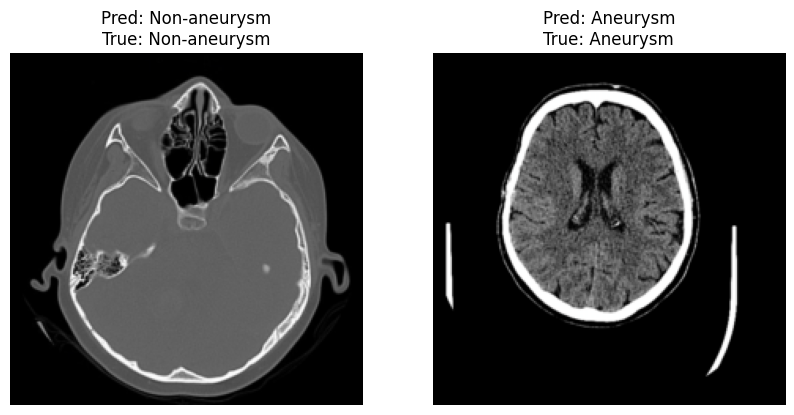

In [ ]:
# Visualize predictions (limited to 2 images)
def visualize_predictions(model, loader, num_images=2):
    model.eval()
    images_shown = 0
    plt.figure(figsize=(10, 5))
    with torch.no_grad():
        for inputs, labels in loader:
            if inputs is None:
                continue
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            for i in range(inputs.size(0)):
                if images_shown >= num_images:
                    break
                img = inputs[i].cpu().permute(1, 2, 0).numpy()
                img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
                img = np.clip(img, 0, 1)
                plt.subplot(1, num_images, images_shown + 1)
                plt.imshow(img)
                plt.title(f"Pred: {'Aneurysm' if preds[i].item() == 1 else 'Non-aneurysm'}\nTrue: {'Aneurysm' if labels[i].item() == 1 else 'Non-aneurysm'}")
                plt.axis('off')
                images_shown += 1
            if images_shown >= num_images:
                break
    plt.show()

visualize_predictions(model, test_loader)

Saving brain scan.jpg to brain scan (5).jpg


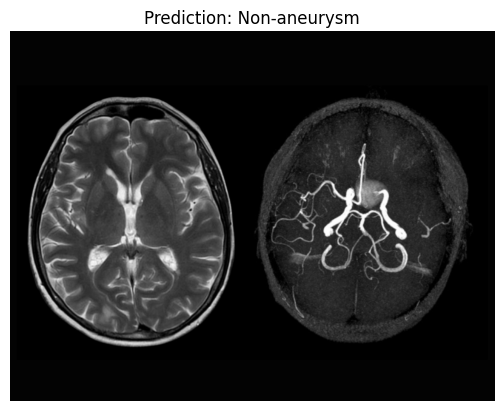

The image is predicted as: Non-aneurysm


In [ ]:
# Import necessary libraries
from google.colab import files
import torch
import numpy as np
import cv2
from PIL import Image
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchvision.models as models

# Set device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Upload image
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Load the uploaded image
image = Image.open(file_name)

# Preprocessing the image (resize, normalize)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Convert image to tensor and add batch dimension
input_tensor = transform(image).unsqueeze(0).float().to(device)

# Define the model
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.vgg16 = models.vgg16(weights='IMAGENET1K_V1')
        for param in self.vgg16.features.parameters():
            param.requires_grad = False
        in_feats = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(in_feats, 2)

    def forward(self, x):
        x = self.vgg16(x)
        return x

# Initialize the model and load weights
model = CNNModel().to(device)
model.load_state_dict(torch.load('model.pth'))  # Load the trained model
model.eval()

# Predict using the model
with torch.no_grad():
    output = model(input_tensor)
    _, pred = torch.max(output, 1)
    label = 'Aneurysm' if pred.item() == 1 else 'Non-aneurysm'

# Display the result
plt.imshow(image)
plt.title(f"Prediction: {label}")
plt.axis('off')
plt.show()

# Display the label of the image
print(f"The image is predicted as: {label}")